In [1]:
# Import necessary library
import pandas as pd
import numpy as np

# Load the dataset (replace path with your file location)
df = pd.read_csv("ecommers_sales.csv", low_memory=False)

In [2]:
print(" First 10 rows of the dataset:")
print(df.head(10))

 First 10 rows of the dataset:
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   
5      5  404-1490984-4578765  04-30-22                       Shipped   
6      6  408-5748499-6859555  04-30-22                       Shipped   
7      7  406-7807733-3785945  04-30-22  Shipped - Delivered to Buyer   
8      8  407-5443024-5233168  04-30-22                     Cancelled   
9      9  402-4393761-0311520  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style                  SKU  \
0   Merchant      Amazon.in           Standard   SET389       SET389-KR-NP-S   
1   M

In [3]:
# Display basic dataset info
print("\n🔹 Dataset Information:")
print(df.info())


🔹 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount    

In [4]:
# Display dataset shape (rows and columns)
print(f"\n🔹 Dataset Shape: {df.shape}")

# Check for missing values
print("\n🔹 Missing Values in Each Column:")
print(df.isnull().sum())

# Check for duplicate records
print(f"\n🔹 Duplicate Rows: {df.duplicated().sum()}")


🔹 Dataset Shape: (128975, 24)

🔹 Missing Values in Each Column:
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

🔹 Duplicate Rows: 0


In [5]:
#  1. Remove unnecessary columns
# The 'index' and 'Unnamed: 22' columns don’t add analytical value
df.drop(columns=['index', 'Unnamed: 22'], inplace=True, errors='ignore')

#  2. Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='%m-%d-%y')

#  3. Handle missing values
# Fill missing numeric values (e.g., Amount) with 0
df['Amount'] = df['Amount'].fillna(0)

# Fill missing text/categorical fields with 'Unknown'
for col in ['currency', 'Courier Status', 'ship-city', 'ship-state', 
            'ship-country', 'promotion-ids', 'fulfilled-by']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

#  4. Remove duplicate rows (if any)
df.drop_duplicates(inplace=True)

#  5. Verify data types after cleaning
print("🔹 Data Types After Cleaning:\n", df.dtypes)

#  6. Summary of missing values
print("\n🔹 Missing Values After Cleaning:\n", df.isnull().sum())

#  7. Display sample of cleaned dataset
print("\n🔹 First 10 Rows of Cleaned Dataset:")
print(df.head(10))

#  8. (Optional) Save cleaned data for further analysis
df.to_csv("cleaned_ecommerce_sales.csv", index=False)
print("\n Cleaned dataset saved as 'cleaned_ecommerce_sales.csv'")

🔹 Data Types After Cleaning:
 Order ID                      object
Date                  datetime64[ns]
Status                        object
Fulfilment                    object
Sales Channel                 object
ship-service-level            object
Style                         object
SKU                           object
Category                      object
Size                          object
ASIN                          object
Courier Status                object
Qty                            int64
currency                      object
Amount                       float64
ship-city                     object
ship-state                    object
ship-postal-code             float64
ship-country                  object
promotion-ids                 object
B2B                             bool
fulfilled-by                  object
dtype: object

🔹 Missing Values After Cleaning:
 Order ID               0
Date                   0
Status                 0
Fulfilment             0
Sales C

In [8]:
# -------------------- STEP 1: HANDLE MISSING VALUES --------------------
# Check missing values
print("🔹 Missing Values Before Cleaning:")
print(df.isnull().sum())

# Drop irrelevant columns
df.drop(columns=['index', 'Unnamed: 22'], inplace=True, errors='ignore')

# Fill missing numeric columns
if 'Amount' in df.columns:
    df['Amount'] = df['Amount'].fillna(df['Amount'].median())

# Fill missing text columns with 'Unknown'
for col in ['currency', 'Courier Status', 'ship-city', 'ship-state', 'ship-country',
            'promotion-ids', 'fulfilled-by']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# -------------------- STEP 2: REMOVE DUPLICATE RECORDS --------------------
# Drop duplicates based on key columns
df.drop_duplicates(subset=['Order ID'], inplace=True)

# -------------------- STEP 3: CORRECT DATA TYPES --------------------
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='%m-%d-%y')

# Convert 'Qty' to integer
df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce').fillna(0).astype(int)

# Ensure 'Amount' is numeric
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce').fillna(0)

# -------------------- STEP 4: FIX DATA INCONSISTENCIES --------------------
# Standardize text columns (strip spaces and lowercase)
text_cols = ['Status', 'Fulfilment', 'Sales Channel', 'ship-service-level', 
             'Category', 'ship-city', 'ship-state', 'ship-country']

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# Remove negative or unrealistic values
df = df[df['Amount'] >= 0]
df = df[df['Qty'] > 0]

# -------------------- STEP 5: HANDLE OUTLIERS --------------------
# Use IQR (Interquartile Range) method to remove extreme outliers in 'Amount'
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df = df[(df['Amount'] >= lower_bound) & (df['Amount'] <= upper_bound)]

# -------------------- STEP 6: CREATE NEW COLUMNS --------------------
# Create 'Total Revenue' (Qty * Amount)
df['Total Revenue'] = df['Qty'] * df['Amount']

# Extract date components
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()

# -------------------- STEP 7: SAVE CLEANED DATASET --------------------
df.to_csv("cleaned_ecommerce_sales.csv", index=False)

# -------------------- SUMMARY OUTPUT --------------------
print("\n Data Cleaning Completed Successfully!")
print(f" Cleaned Dataset Shape: {df.shape}")
print("\n🔹 Sample of Cleaned Data:")
print(df.head(10))
print("\n Cleaned dataset saved as 'cleaned_ecommerce_sales.csv'")

🔹 Missing Values Before Cleaning:
Order ID               0
Date                   0
Status                 0
Fulfilment             0
Sales Channel          0
ship-service-level     0
Style                  0
SKU                    0
Category               0
Size                   0
ASIN                   0
Courier Status         0
Qty                    0
currency               0
Amount                 0
ship-city              0
ship-state             0
ship-postal-code      33
ship-country           0
promotion-ids          0
B2B                    0
fulfilled-by           0
dtype: int64

 Data Cleaning Completed Successfully!
 Cleaned Dataset Shape: (105042, 27)

🔹 Sample of Cleaned Data:
               Order ID       Date                        Status Fulfilment  \
1   171-9198151-1101146 2022-04-30  Shipped - Delivered To Buyer   Merchant   
2   404-0687676-7273146 2022-04-30                       Shipped     Amazon   
4   407-1069790-7240320 2022-04-30                       Shipp

In [11]:
# Subtask 4: Exploratory Data Analysis (EDA) Summary Report

import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("cleaned_ecommerce_sales.csv")

# -------------------- STEP 1: BASIC OVERVIEW --------------------
print("🔹 Dataset Shape:", df.shape)
print("\n🔹 Columns:", df.columns.tolist())
print("\n🔹 Summary Statistics:")
print(df.describe())

# -------------------- STEP 2: KEY METRICS --------------------
# Total revenue and total quantity sold
total_revenue = df['Total Revenue'].sum()
total_orders = df['Order ID'].nunique()
total_qty = df['Qty'].sum()

print("\n💰 Total Revenue: ₹{:,.2f}".format(total_revenue))
print("📦 Total Quantity Sold:", total_qty)
print("🧾 Total Unique Orders:", total_orders)

# -------------------- STEP 3: TOP-SELLING CATEGORIES --------------------
top_categories = (
    df.groupby('Category')['Total Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\n🏆 Top 10 Product Categories by Revenue:")
print(top_categories)

# -------------------- STEP 4: MONTHLY SALES TREND --------------------
# Ensure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)

monthly_sales = (
    df.groupby('Month_Year')['Total Revenue']
    .sum()
    .sort_index()
)

print("\n📅 Monthly Sales Trend:")
print(monthly_sales)

# -------------------- STEP 5: STATE-WISE REVENUE --------------------
top_states = (
    df.groupby('ship-state')['Total Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\n📍 Top 10 States by Revenue:")
print(top_states)

# -------------------- STEP 6: OUTPUT SUMMARY --------------------
print("\n✅ EDA Summary Report Completed!")
print("Use visualizations (matplotlib/seaborn) for deeper trend analysis.")

🔹 Dataset Shape: (105042, 27)

🔹 Columns: ['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Total Revenue', 'Year', 'Month', 'Day', 'DayOfWeek']

🔹 Summary Statistics:
                 Qty         Amount  ship-postal-code  Total Revenue  \
count  105042.000000  105042.000000     105019.000000  105042.000000   
mean        1.002409     625.393138     463142.336101     627.290931   
std         0.078688     249.111856     191279.470815     255.979213   
min         1.000000       0.000000     110001.000000       0.000000   
25%         1.000000     442.000000     382424.000000     442.000000   
50%         1.000000     599.000000     500030.000000     599.000000   
75%         1.000000     771.000000     600018.000000     771.000000   
max        15.000000    12

In [12]:
# Extracted and Formatted the Order Date Column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='%m-%d-%y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day


In [13]:
# Monthly sales aggregation
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Revenue'].sum().sort_index()

# Yearly sales aggregation
yearly_sales = df.groupby(df['Date'].dt.year)['Total Revenue'].sum().sort_index()


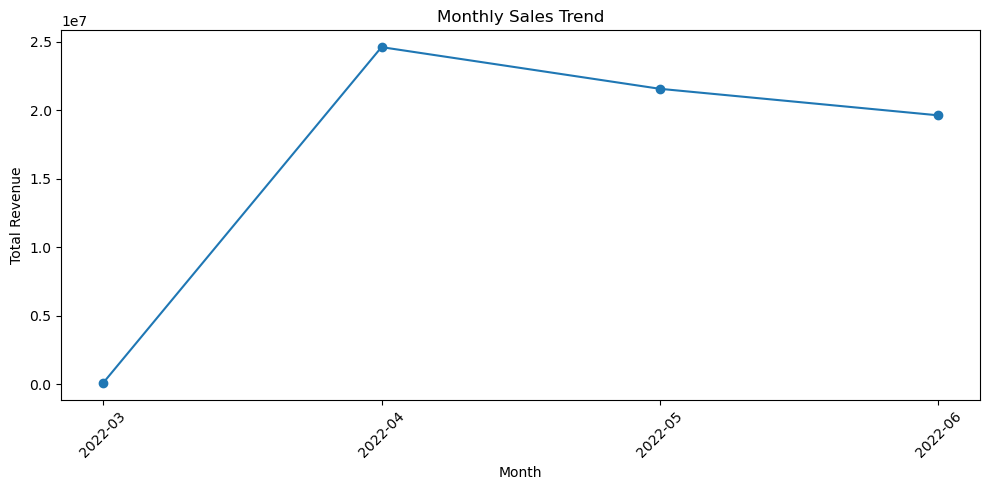

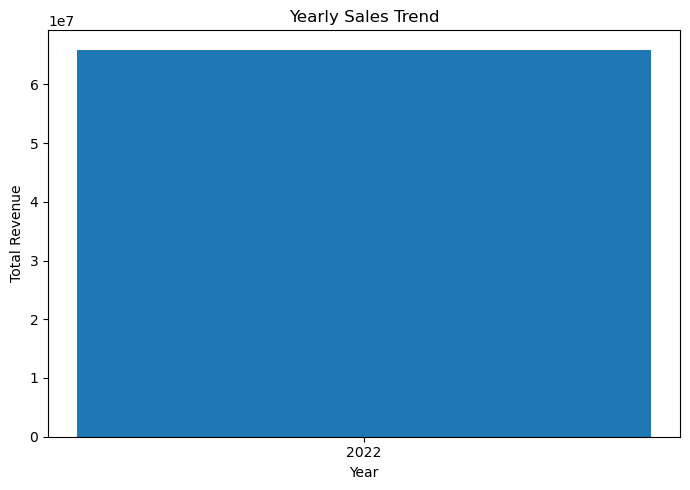

In [14]:
import matplotlib.pyplot as plt

# Line chart – Monthly sales trend
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar chart – Yearly sales trend
plt.figure(figsize=(7,5))
plt.bar(yearly_sales.index.astype(str), yearly_sales.values)
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


In [15]:
peak_month = monthly_sales.idxmax()
low_month = monthly_sales.idxmin()

print("Peak Month:", peak_month)
print("Low-Performing Month:", low_month)


Peak Month: 2022-04
Low-Performing Month: 2022-03


In [16]:
# Group by product name (SKU or Style)
product_sales = df.groupby('SKU').agg({
    'Qty': 'sum',
    'Total Revenue': 'sum'
}).sort_values(by='Total Revenue', ascending=False)

# Group by category
category_sales = df.groupby('Category').agg({
    'Qty': 'sum',
    'Total Revenue': 'sum'
}).sort_values(by='Total Revenue', ascending=False)


In [17]:
# Calculate top-selling products based on sales and revenue
top_products = df.groupby('SKU').agg({
    'Qty': 'sum',
    'Total Revenue': 'sum'
}).sort_values(by='Total Revenue', ascending=False)

# Display top 10 products
top_10_products = top_products.head(10)
print(top_10_products)

                 Qty  Total Revenue
SKU                                
JNE3797-KR-L     631       458137.0
JNE3797-KR-M     529       384546.0
J0230-SKD-S      353       382581.0
J0230-SKD-M      354       370526.0
JNE3797-KR-S     484       356639.0
JNE3797-KR-XL    394       292869.0
JNE3797-KR-XS    368       272520.0
SET268-KR-NP-XL  356       269432.0
SET268-KR-NP-S   329       249912.0
JNE3797-KR-XXL   345       248172.0


In [18]:
category_sales = df.groupby('Category').agg({
    'Qty': 'sum',
    'Total Revenue': 'sum'
}).sort_values(by='Total Revenue', ascending=False)

print(category_sales.head(10))


                 Qty  Total Revenue
Category                           
Set            39180     30728237.0
Kurta          41355     18904444.0
Western Dress  13149     10014052.0
Top             9324      4908830.0
Ethnic Dress     963       680656.0
Blouse           830       425041.0
Bottom           368       131704.0
Saree            125        98625.0
Dupatta            1          305.0


<Axes: title={'center': 'Top Categories by Revenue'}, xlabel='Category'>

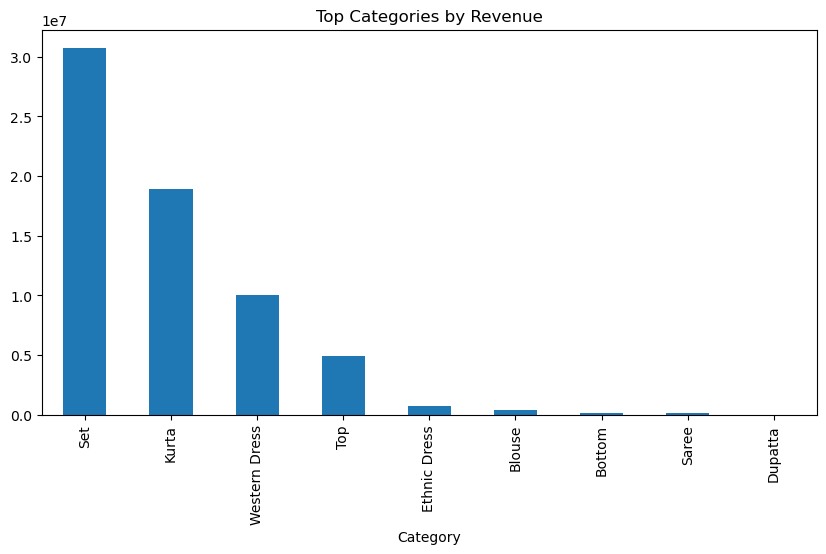

In [20]:
category_sales['Total Revenue'].plot(kind='bar', figsize=(10,5), title='Top Categories by Revenue')


<Axes: ylabel='Total Revenue'>

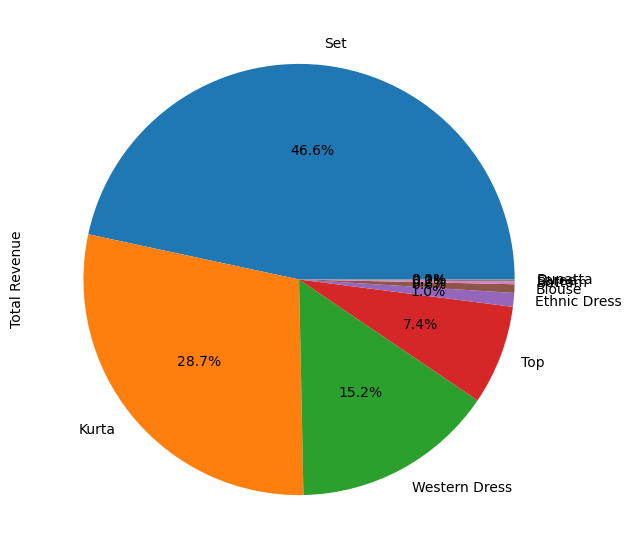

In [21]:
category_sales['Total Revenue'].plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))


In [22]:
#Calculated Total Sales and Revenue by Location

geo_sales = df.groupby('ship-state').agg({
    'Qty': 'sum',
    'Total Revenue': 'sum'
}).sort_values(by='Total Revenue', ascending=False)

print(geo_sales.head(10))


                  Qty  Total Revenue
ship-state                          
Maharashtra     18442     11320608.0
Karnataka       14409      8966146.0
Telangana        9117      5724234.0
Uttar Pradesh    8622      5677505.0
Tamil Nadu       9323      5469494.0
Delhi            5742      3669733.0
Kerala           5270      3214628.0
West Bengal      4899      3002424.0
Andhra Pradesh   4265      2605564.0
Haryana          3650      2404379.0


In [23]:
#Identify Top & Low Performing Regions
# Fix numeric fields
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce').fillna(0)
df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce').fillna(0)

# Create total revenue
df['Total Revenue'] = df['Amount'] * df['Qty']

# Group by state (location)
geo_sales = df.groupby('ship-state').agg({
    'Qty': 'sum',
    'Total Revenue': 'sum'
}).sort_values(by='Total Revenue', ascending=False)

# Print top-performing regions
print("TOP 5 PERFORMING STATES:")
print(geo_sales.head(5))
print("\n")

# Print low-performing regions
print("LOW 5 PERFORMING STATES:")
print(geo_sales.tail(5))

TOP 5 PERFORMING STATES:
                 Qty  Total Revenue
ship-state                         
Maharashtra    18442     11320608.0
Karnataka      14409      8966146.0
Telangana       9117      5724234.0
Uttar Pradesh   8622      5677505.0
Tamil Nadu      9323      5469494.0


LOW 5 PERFORMING STATES:
                        Qty  Total Revenue
ship-state                                
Punjab/Mohali/Zirakpur    1          568.0
Rajshthan                 1          563.0
Pondicherry               1          529.0
Ar                        1          493.0
Pb                        1          399.0


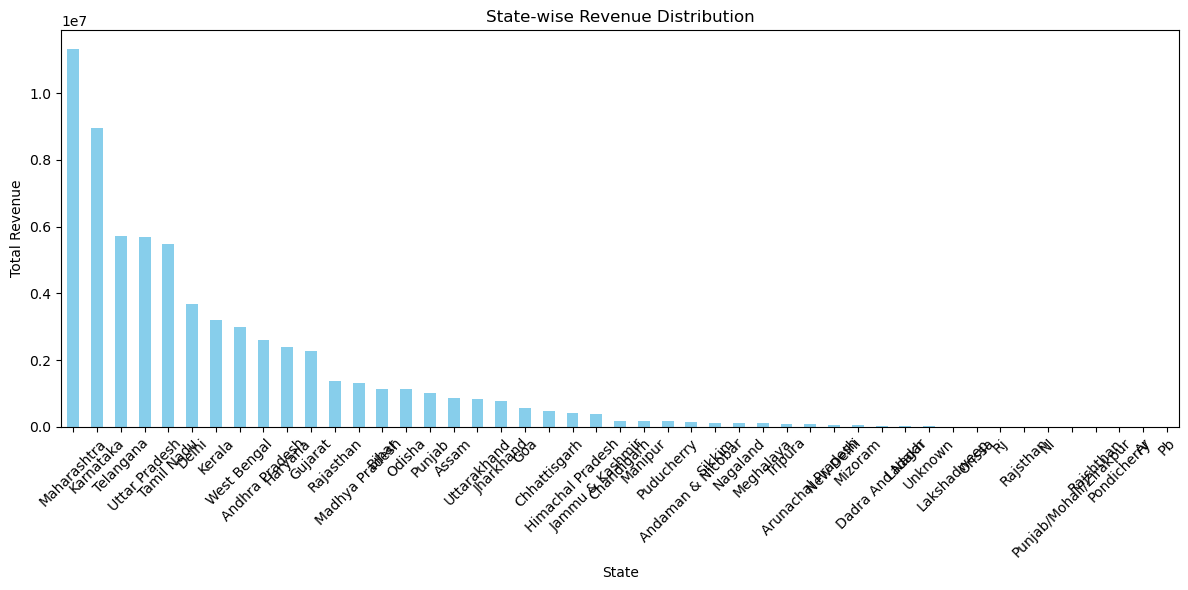

In [24]:
#Bar Chart – Revenue by State
# Clean numeric fields
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce').fillna(0)
df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce').fillna(0)
df['Total Revenue'] = df['Amount'] * df['Qty']

# Group by state
geo_sales = df.groupby('ship-state')['Total Revenue'].sum().sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(12,6))
geo_sales.plot(kind='bar', color='skyblue')
plt.title("State-wise Revenue Distribution")
plt.xlabel("State")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

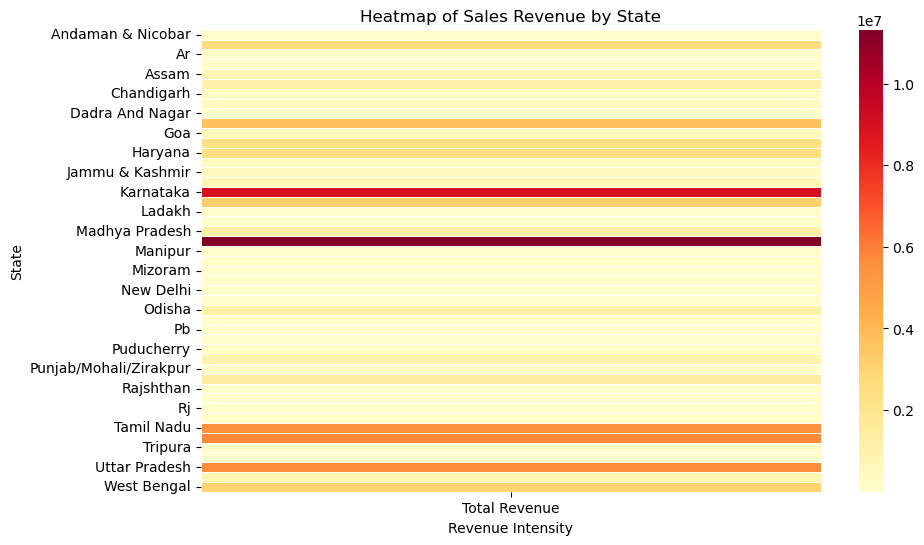

In [25]:
#Heatmap – Revenue by State
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to dataframe for heatmap
geo_df = geo_sales.reset_index()

plt.figure(figsize=(10,6))
sns.heatmap(geo_df.pivot_table(values='Total Revenue',
                               index='ship-state'),
                               cmap="YlOrRd", linewidths=.5)

plt.title("Heatmap of Sales Revenue by State")
plt.ylabel("State")
plt.xlabel("Revenue Intensity")
plt.show()

In [27]:
reference_date = df['Date'].max()
print("Reference Date:", reference_date)


Reference Date: 2022-06-29 00:00:00


In [31]:
import pandas as pd

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Reference date = latest order date
reference_date = df['Date'].max()

# Create RFM table (each order = 1 customer)
rfm = pd.DataFrame()
rfm['Order'] = df['Order ID']
rfm['Recency'] = (reference_date - df['Date']).dt.days
rfm['Frequency'] = 1
rfm['Monetary'] = df['Total Revenue']

# Rank-based scoring (stable and error-free)
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1])
rfm['F_Score'] = 5  # all orders have frequency = 1
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Combine RFM scores
rfm['RFM_Segment'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

print(rfm.head())


                 Order  Recency  Frequency  Monetary R_Score  F_Score M_Score  \
0  171-9198151-1101146       60          1     406.0       2        5       2   
1  404-0687676-7273146       60          1     329.0       2        5       1   
2  407-1069790-7240320       60          1     574.0       2        5       3   
3  404-1490984-4578765       60          1     824.0       2        5       5   
4  408-5748499-6859555       60          1     653.0       2        5       3   

  RFM_Segment  RFM_Score  
0         252          9  
1         251          8  
2         253         10  
3         255         12  
4         253         10  


In [32]:
def segment_customer(rfm_score):
    if rfm_score >= 13:
        return 'High-Value'
    elif rfm_score >= 9:
        return 'Medium-Value'
    elif rfm_score >= 6:
        return 'At-Risk'
    else:
        return 'Lost'

rfm['Customer Segment'] = rfm['RFM_Score'].apply(segment_customer)

# Display result
print(rfm[['Order', 'RFM_Score', 'Customer Segment']].head())


                 Order  RFM_Score Customer Segment
0  171-9198151-1101146          9     Medium-Value
1  404-0687676-7273146          8          At-Risk
2  407-1069790-7240320         10     Medium-Value
3  404-1490984-4578765         12     Medium-Value
4  408-5748499-6859555         10     Medium-Value


In [33]:
# Define segmentation logic
def assign_segment(rfm_score):
    if rfm_score >= 13:
        return 'High-Value'
    elif rfm_score >= 9:
        return 'Medium-Value'
    elif rfm_score >= 6:
        return 'At-Risk'
    else:
        return 'Lost'

# Apply segmentation
rfm['Customer Segment'] = rfm['RFM_Score'].apply(assign_segment)

# Display result (use correct column name)
print(rfm[['Order', 'RFM_Score', 'Customer Segment']].head())


                 Order  RFM_Score Customer Segment
0  171-9198151-1101146          9     Medium-Value
1  404-0687676-7273146          8          At-Risk
2  407-1069790-7240320         10     Medium-Value
3  404-1490984-4578765         12     Medium-Value
4  408-5748499-6859555         10     Medium-Value


In [39]:
# Segment-wise purchase behavior analysis
segment_analysis = rfm.groupby('Customer Segment').agg({
    'Recency': ['mean', 'min', 'max'],
    'Monetary': ['mean', 'sum'],
    'Order': 'count'
}).reset_index()

# Rename columns for clarity
segment_analysis.columns = [
    'Customer Segment',
    'Avg Recency',
    'Min Recency',
    'Max Recency',
    'Avg Monetary Value',
    'Total Revenue',
    'Number of Orders'
]

print(segment_analysis)


  Customer Segment  Avg Recency  Min Recency  Max Recency  Avg Monetary Value  \
0          At-Risk    76.453913           58           90          374.629740   
1       High-Value    23.452800            0           58          852.369542   
2     Medium-Value    51.231551            0           90          589.678904   

   Total Revenue  Number of Orders  
0      5275536.0             14082  
1     22645754.0             26568  
2     37970604.0             64392  


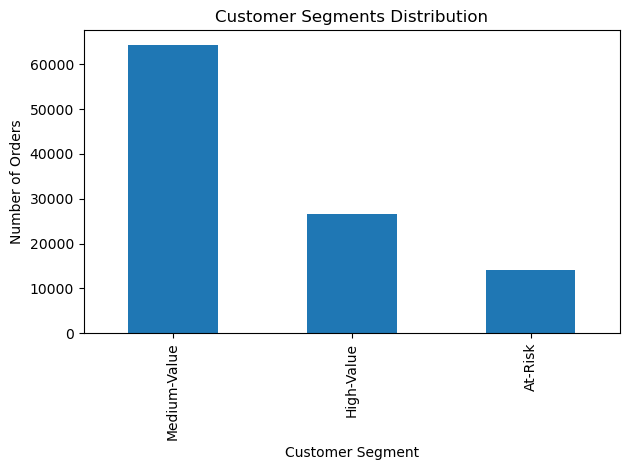

In [41]:
import matplotlib.pyplot as plt

# Count orders per segment
segment_counts = rfm['Customer Segment'].value_counts()

# Bar chart
segment_counts.plot(kind='bar', title='Customer Segments Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()



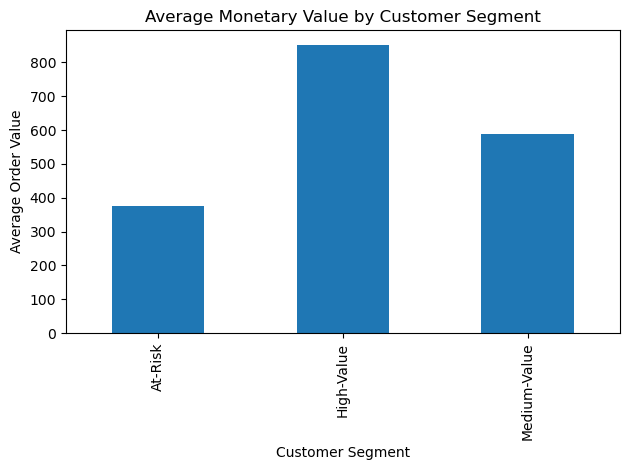

In [45]:
# Average spending per segment
avg_spend = rfm.groupby('Customer Segment')['Monetary'].mean()

avg_spend.plot(kind='bar', title='Average Monetary Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Order Value')
plt.tight_layout()
plt.show()


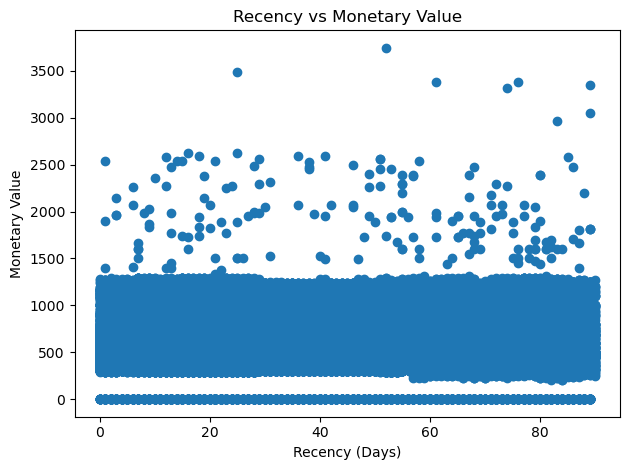

In [47]:
plt.scatter(rfm['Recency'], rfm['Monetary'])
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.title('Recency vs Monetary Value')
plt.tight_layout()
plt.show()


In [48]:
#Prepared Data by Ensuring Each Customer Is Assigned to an RFM Segment Code
# Check missing segments
print(rfm['Customer Segment'].isnull().sum())

# View sample data
rfm[['Order', 'RFM_Score', 'Customer Segment']].head()


0


,Order,RFM_Score,Customer Segment
0,171-9198151-1101146,9,Medium-Value
1,404-0687676-7273146,8,At-Risk
2,407-1069790-7240320,10,Medium-Value
3,404-1490984-4578765,12,Medium-Value
4,408-5748499-6859555,10,Medium-Value


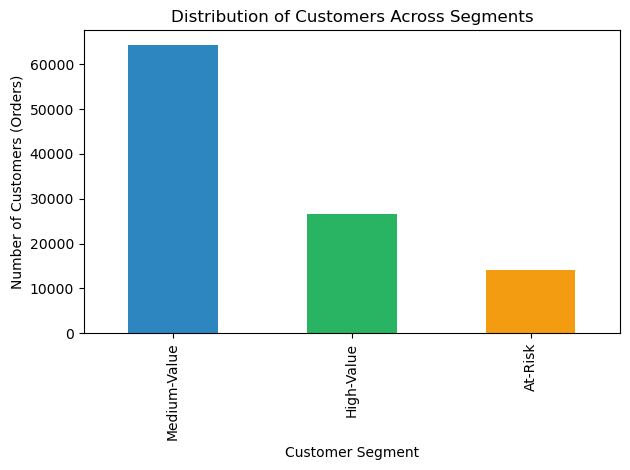

In [49]:
#Created a Bar Chart to Show the Distribution of Customers Across Segments
import matplotlib.pyplot as plt

# Count customers in each segment
segment_counts = rfm['Customer Segment'].value_counts()

# Create bar chart with colors
segment_counts.plot(
    kind='bar',
    color=['#2E86C1', '#28B463', '#F39C12', '#E74C3C']
)

plt.title('Distribution of Customers Across Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers (Orders)')
plt.tight_layout()
plt.show()


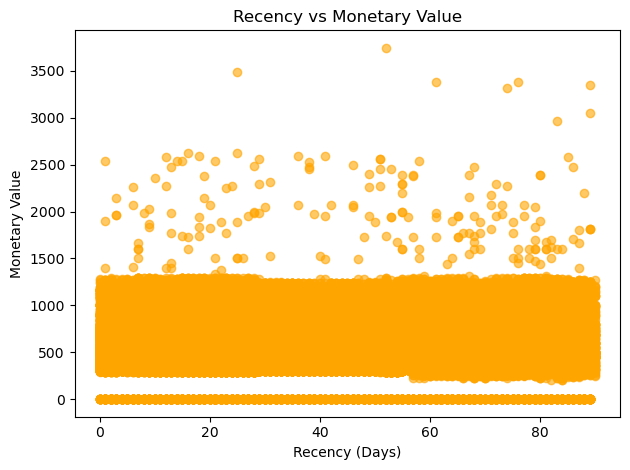

In [55]:
#Visualized RFM score relationships using scatter plots or bubble charts.
import matplotlib.pyplot as plt

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    color='orange',
    alpha=0.6
)

plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.title('Recency vs Monetary Value')
plt.tight_layout()
plt.show()



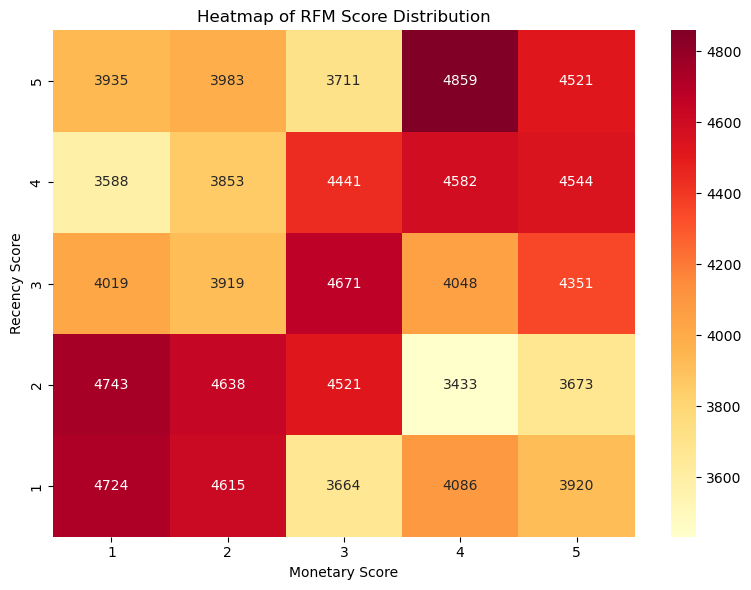

In [58]:
#Generated a Heatmap to Identify Density Patterns in RFM Scores
import seaborn as sns
import matplotlib.pyplot as plt

# Create RFM heatmap data (Recency vs Monetary scores)
rfm_heatmap = (
    rfm
    .groupby(['R_Score', 'M_Score'], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(rfm_heatmap, annot=True, fmt='d', cmap='YlOrRd')

plt.title('Heatmap of RFM Score Distribution')
plt.xlabel('Monetary Score')
plt.ylabel('Recency Score')
plt.tight_layout()
plt.show()


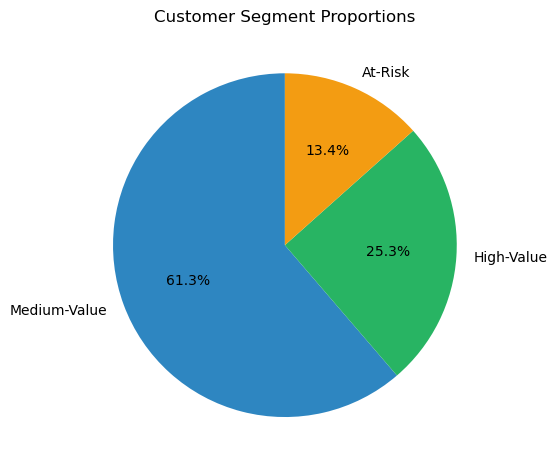

In [60]:
import matplotlib.pyplot as plt

# Count customers in each segment
segment_counts = rfm['Customer Segment'].value_counts()

# Create pie chart
segment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2E86C1', '#28B463', '#F39C12', '#E74C3C']
)

plt.title('Customer Segment Proportions')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [64]:
#Step 4: Sales Forecasting Using Time Series Analysis

#Task 1: Formatted Date Column Correctly into Datetime Format

import pandas as pd

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')



In [65]:
#Daily Sales Aggregation

# Daily sales aggregation
daily_sales = df.groupby('Date')['Total Revenue'].sum().reset_index()

print(daily_sales.head())

        Date  Total Revenue
0 2022-03-31        89254.0
1 2022-04-01       733214.0
2 2022-04-02       777247.0
3 2022-04-03       875628.0
4 2022-04-04       774420.0


In [67]:
#Weekly Sales Aggregation

# Weekly sales aggregation
weekly_sales = (
    df.set_index('Date')
      .resample('W')['Total Revenue']
      .sum()
      .reset_index()
)

print(weekly_sales.head())

        Date  Total Revenue
0 2022-04-03      2475343.0
1 2022-04-10      5742570.0
2 2022-04-17      5880205.0
3 2022-04-24      6014772.0
4 2022-05-01      5505214.0


In [69]:
# Monthly sales aggregation (Month-End)
monthly_sales = (
    df.set_index('Date')
      .resample('ME')['Total Revenue']
      .sum()
      .reset_index()
)

print(monthly_sales.head())


        Date  Total Revenue
0 2022-03-31        89254.0
1 2022-04-30     24608928.0
2 2022-05-31     21565244.0
3 2022-06-30     19628468.0


In [70]:
# Check for missing values in the dataset
df.isnull().sum()


Order ID               0
Date                   0
Status                 0
Fulfilment             0
Sales Channel          0
ship-service-level     0
Style                  0
SKU                    0
Category               0
Size                   0
ASIN                   0
Courier Status         0
Qty                    0
currency               0
Amount                 0
ship-city              0
ship-state             0
ship-postal-code      23
ship-country           0
promotion-ids          0
B2B                    0
fulfilled-by           0
Total Revenue          0
Year                   0
Month                  0
Day                    0
DayOfWeek              0
Month_Year             0
dtype: int64

In [71]:
# Ensure Date is index
daily_sales = df.groupby('Date')['Total Revenue'].sum()
daily_sales = daily_sales.sort_index()

# Create full date range
full_range = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq='D'
)

# Identify missing dates
missing_dates = full_range.difference(daily_sales.index)
print("Number of missing dates:", len(missing_dates))


Number of missing dates: 0


In [72]:
# Reindex and fill missing dates with 0 sales
daily_sales = daily_sales.reindex(full_range, fill_value=0)
daily_sales.index.name = 'Date'


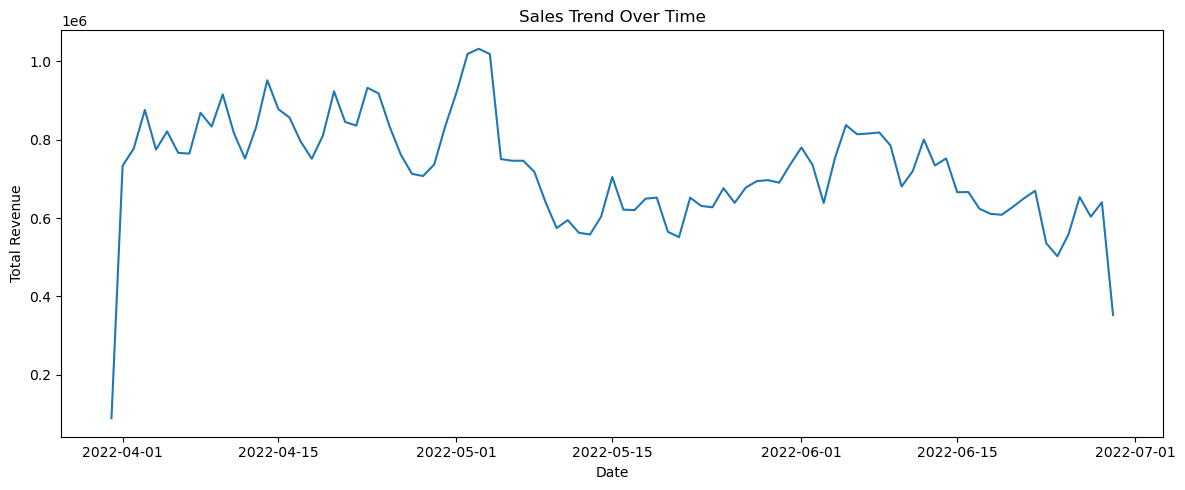

In [76]:
#Identified Sales Trends
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

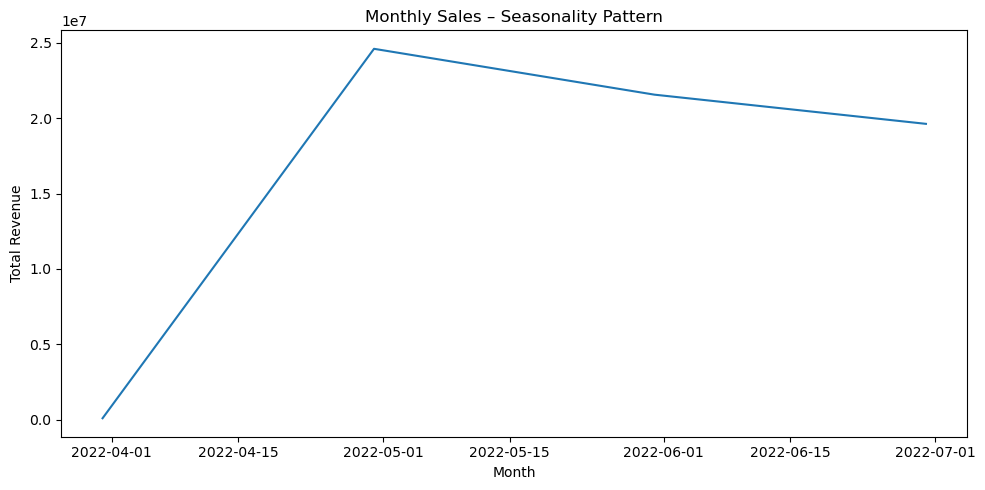

In [82]:
#Identified Seasonality
# Monthly sales aggregation from daily series
monthly_sales = daily_sales.resample('ME').sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Sales – Seasonality Pattern')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()



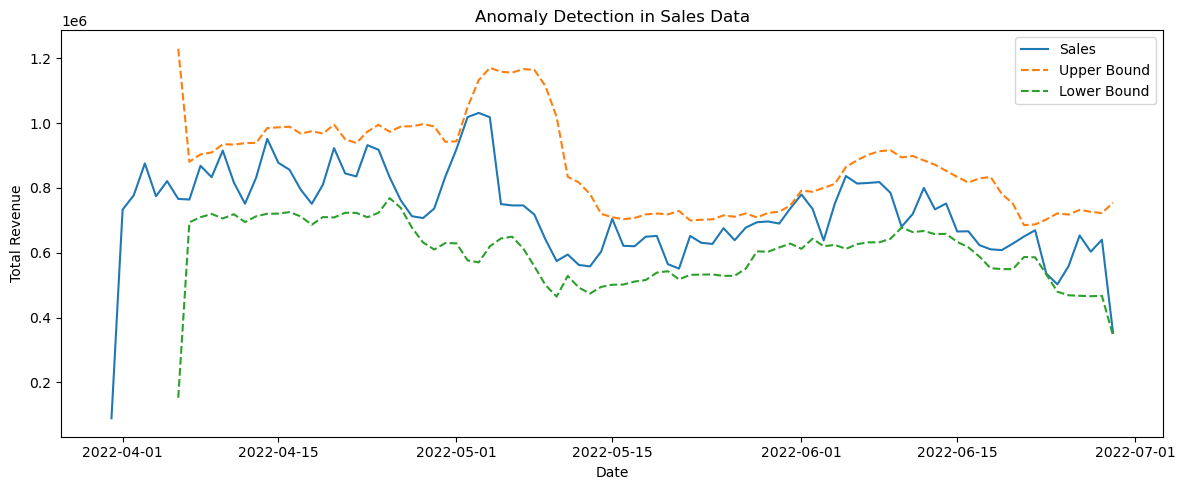

In [84]:
#Identified Anomalies (Spikes & Drops)
import matplotlib.pyplot as plt

# Rolling statistics on daily sales (Series)
rolling_mean = daily_sales.rolling(window=7).mean()
rolling_std = daily_sales.rolling(window=7).std()

upper_bound = rolling_mean + 2 * rolling_std
lower_bound = rolling_mean - 2 * rolling_std

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values, label='Sales')
plt.plot(upper_bound.index, upper_bound.values, linestyle='--', label='Upper Bound')
plt.plot(lower_bound.index, lower_bound.values, linestyle='--', label='Lower Bound')
plt.legend()
plt.title('Anomaly Detection in Sales Data')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()



In [85]:
# Ensure daily sales data is sorted by date
daily_sales = daily_sales.sort_index()

# Confirm Date is the index
print(daily_sales.head())


Date
2022-03-31     89254.0
2022-04-01    733214.0
2022-04-02    777247.0
2022-04-03    875628.0
2022-04-04    774420.0
Freq: D, Name: Total Revenue, dtype: float64


In [87]:
# Convert Series to DataFrame for saving
daily_sales_df = daily_sales.to_frame(name='Total Revenue')

# Save to CSV
daily_sales_df.to_csv('daily_sales_time_series.csv')


In [91]:
# Save processed time series data
daily_sales.to_csv('daily_sales_time_series.csv')


In [93]:
# Split data into training (80%) and testing (20%)
train_size = int(len(daily_sales) * 0.8)

train_data = daily_sales[:train_size]
test_data = daily_sales[train_size:]

print("Training data size:", len(train_data))
print("Testing data size:", len(test_data))


Training data size: 72
Testing data size: 19


In [95]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Train Holt-Winters model on training data
hw_model = ExponentialSmoothing(
    train_data,
    trend='add',
    seasonal='add',
    seasonal_periods=30  # monthly seasonality for daily data
)

hw_fit = hw_model.fit()


C:\Users\Navinya\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [97]:
# Forecast next 6 months (180 days)
forecast_6_months = hw_fit.forecast(180)


In [99]:
# Forecast next 12 months (365 days)
forecast_12_months = hw_fit.forecast(365)


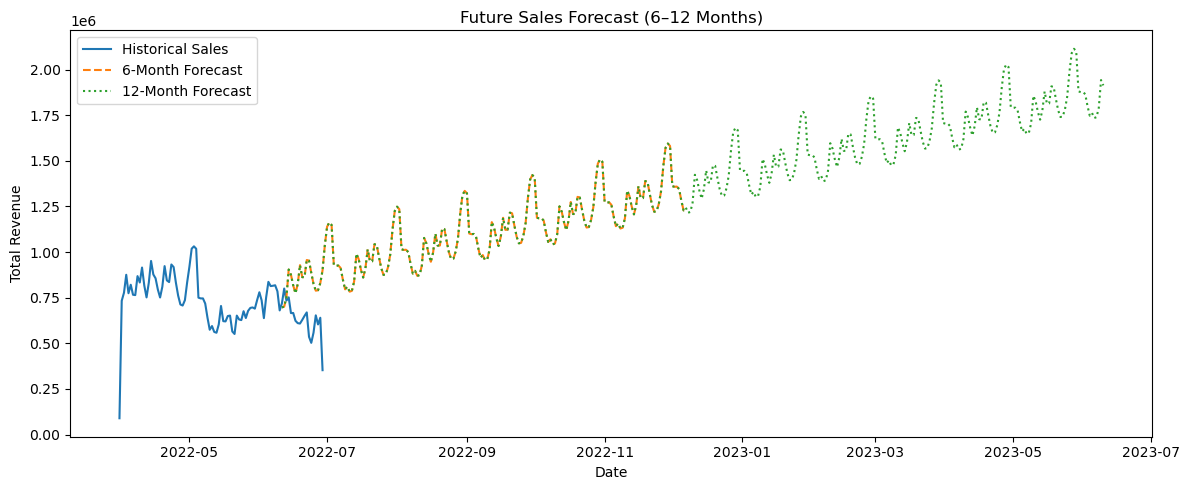

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values, label='Historical Sales')
plt.plot(forecast_6_months.index, forecast_6_months.values,
         linestyle='--', label='6-Month Forecast')
plt.plot(forecast_12_months.index, forecast_12_months.values,
         linestyle=':', label='12-Month Forecast')

plt.title('Future Sales Forecast (6–12 Months)')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.legend()
plt.tight_layout()
plt.show()


In [103]:
# Forecast for the test period
test_forecast = hw_fit.forecast(len(test_data))


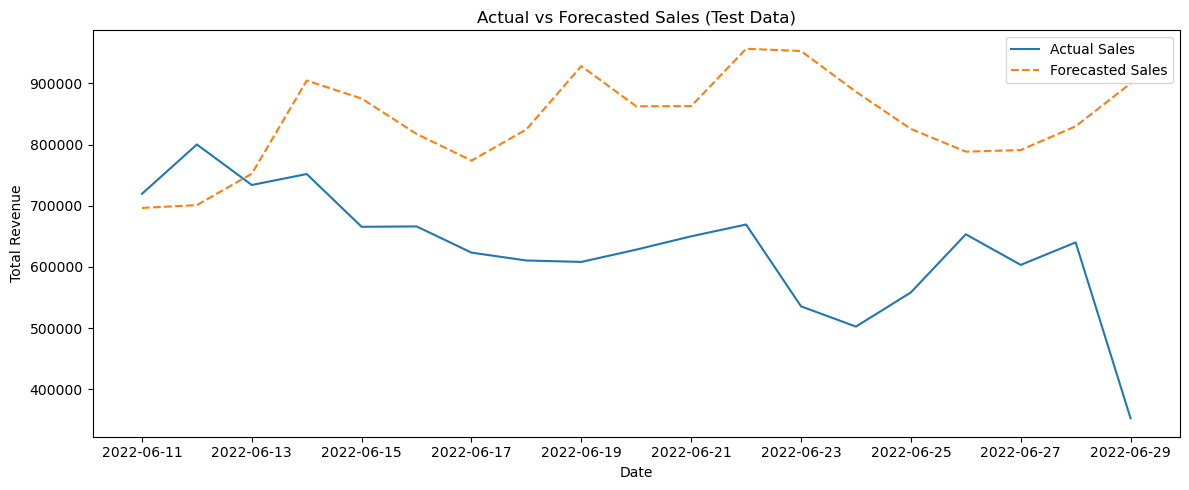

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test_data.index, test_data.values, label='Actual Sales')
plt.plot(test_forecast.index, test_forecast.values,
         linestyle='--', label='Forecasted Sales')

plt.title('Actual vs Forecasted Sales (Test Data)')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.legend()
plt.tight_layout()
plt.show()


In [107]:
import numpy as np

rmse = np.sqrt(np.mean((test_data - test_forecast) ** 2))
print("RMSE:", rmse)


RMSE: 255068.08030820088


In [109]:
mape = np.mean(np.abs((test_data - test_forecast) / test_data)) * 100
print("MAPE:", mape)


MAPE: 39.78899931430182


In [111]:
# Forecast next 12 months (365 days)
future_forecast = hw_fit.forecast(365)


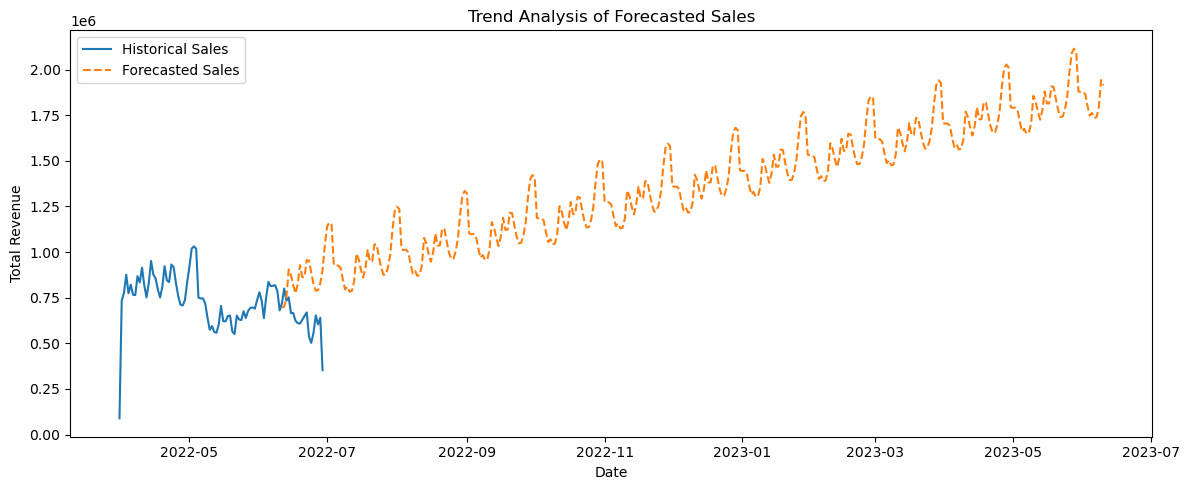

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values, label='Historical Sales')
plt.plot(future_forecast.index, future_forecast.values,
         linestyle='--', label='Forecasted Sales')

plt.title('Trend Analysis of Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.legend()
plt.tight_layout()
plt.show()


In [115]:
# 6-month forecast
forecast_6_months = hw_fit.forecast(180)

# 12-month forecast
forecast_12_months = hw_fit.forecast(365)


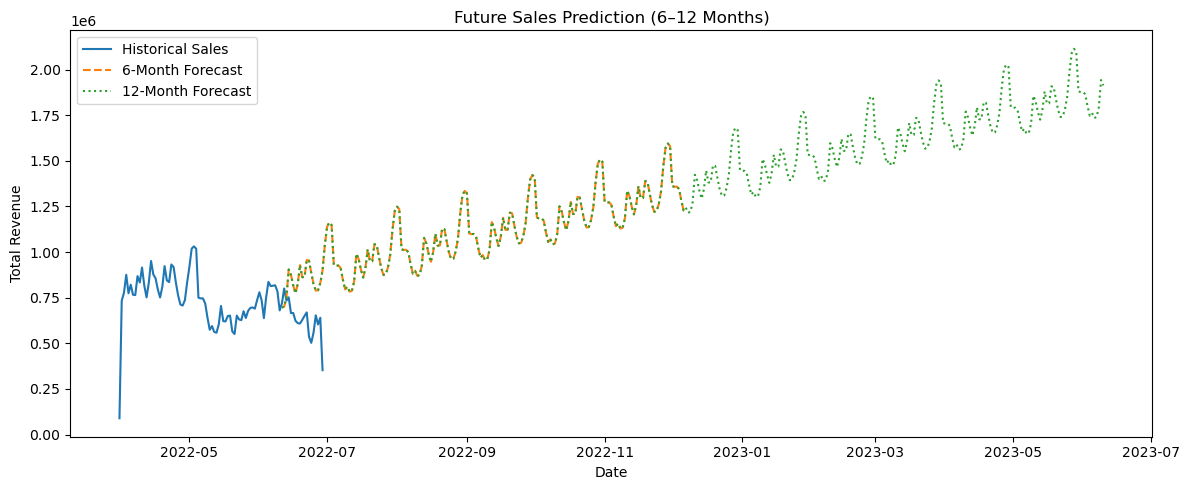

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values, label='Historical Sales')
plt.plot(forecast_6_months.index, forecast_6_months.values,
         linestyle='--', label='6-Month Forecast')
plt.plot(forecast_12_months.index, forecast_12_months.values,
         linestyle=':', label='12-Month Forecast')

plt.title('Future Sales Prediction (6–12 Months)')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.legend()
plt.tight_layout()
plt.show()


In [119]:
import numpy as np

# Forecast for test period
test_forecast = hw_fit.forecast(len(test_data))

# Accuracy metrics
rmse = np.sqrt(np.mean((test_data - test_forecast) ** 2))
mape = np.mean(np.abs((test_data - test_forecast) / test_data)) * 100

print("RMSE:", rmse)
print("MAPE:", mape)


RMSE: 255068.08030820088
MAPE: 39.78899931430182


Top High-Growth Product Categories:
Category
Set              7.682059e+06
Kurta            4.726111e+06
Western Dress    2.503513e+06
Top              1.227208e+06
Ethnic Dress     1.701640e+05
Blouse           1.062602e+05
Bottom           4.390133e+04
Saree            3.287500e+04
Dupatta          3.050000e+02
Name: Total Revenue, dtype: float64


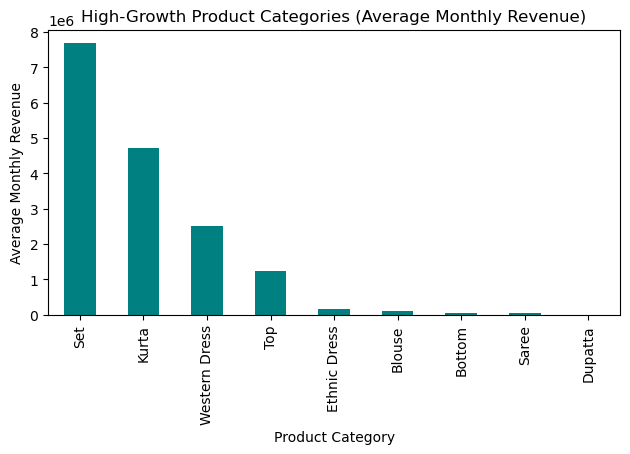

In [129]:
import matplotlib.pyplot as plt

# Aggregate monthly sales by category
category_growth = (
    df.set_index('Date')
      .groupby('Category')['Total Revenue']
      .resample('ME')
      .sum()
      .groupby('Category')
      .mean()
      .sort_values(ascending=False)
)

# Display top categories
print("Top High-Growth Product Categories:")
print(category_growth.head(10))

# Visualize high-growth categories
category_growth.head(10).plot(
    kind='bar',
    color='teal'
)

plt.title('High-Growth Product Categories (Average Monthly Revenue)')
plt.xlabel('Product Category')
plt.ylabel('Average Monthly Revenue')
plt.tight_layout()
plt.show()


Top Performing Regions:
ship-state
Maharashtra       11320608.0
Karnataka          8966146.0
Telangana          5724234.0
Uttar Pradesh      5677505.0
Tamil Nadu         5469494.0
Delhi              3669733.0
Kerala             3214628.0
West Bengal        3002424.0
Andhra Pradesh     2605564.0
Haryana            2404379.0
Name: Total Revenue, dtype: float64


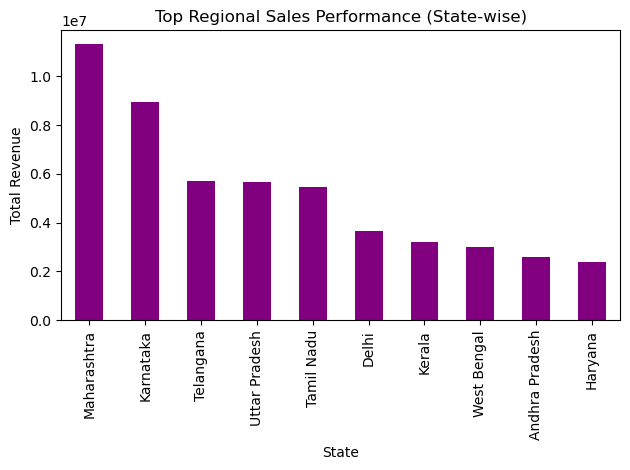

In [131]:
import matplotlib.pyplot as plt

# Aggregate total sales by state
regional_sales = (
    df.groupby('ship-state')['Total Revenue']
      .sum()
      .sort_values(ascending=False)
)

# Display top regions
print("Top Performing Regions:")
print(regional_sales.head(10))

# Visualize regional sales
regional_sales.head(10).plot(
    kind='bar',
    color='purple'
)

plt.title('Top Regional Sales Performance (State-wise)')
plt.xlabel('State')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()
